In [44]:
import numpy as np
import pandas as pd
from tslearn.shapelets import ShapeletModel, grabocka_params_to_shapelet_size_dict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Carica dati (adatta path e colonne)
df = pd.read_csv('/Users/chiaracap/Downloads/06_TS_Understanding/TS_NO_OUTLIERS.csv')
X_ts = df.iloc[:, 1:101].values
X_extra = df.iloc[:, 103:126].values
y = df.iloc[:, 102].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler_ts = StandardScaler()
X_ts_scaled = scaler_ts.fit_transform(X_ts)

# Calcola shapelet_sizes con la funzione grabocka_params_to_shapelet_size_dict
shapelet_sizes = grabocka_params_to_shapelet_size_dict(
    n_ts=X_ts_scaled.shape[0],
    ts_sz=X_ts_scaled.shape[1],
    n_classes=len(np.unique(y_encoded)),
    l=0.1,    # lunghezza media shapelet = 10% della serie temporale
    r=5       # shapelet per classe
)

print("Shapelet sizes dict:", shapelet_sizes)

shp_model = ShapeletModel(
    n_shapelets_per_size=shapelet_sizes,
    optimizer='adam',
    weight_regularizer=0.01,
    max_iter=100,
    random_state=42,
    verbose=1
)

shp_model.fit(X_ts_scaled, y_encoded)
X_shp = shp_model.transform(X_ts_scaled)

scaler_extra = StandardScaler()
X_extra_scaled = scaler_extra.fit_transform(X_extra)

X_combined = np.hstack([X_shp, X_extra_scaled])

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Test accuracy:", clf.score(X_test, y_test))
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))


Shapelet sizes dict: {10: 5, 20: 5, 30: 5, 40: 5, 50: 5}


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tslearn/shapelets/shapelets.py:354: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and 

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.2862 - categorical_crossentropy: 2.0871 - loss: 2.1774
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.2965 - categorical_crossentropy: 1.8579 - loss: 1.9477
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.3118 - categorical_crossentropy: 1.7892 - loss: 1.8786
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.3182 - categorical_crossentropy: 1.7570 - loss: 1.8459
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.3289 - categorical_crossentropy: 1.7147 - loss: 1.8031
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.3318 - categorical_crossentropy: 1.6669 - loss: 1.7549
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.3301 - categorical_crossentropy: 1.6288 - loss: 1.7165
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.3354 - 

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Test accuracy: 0.5067264573991032
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.56      0.19      0.29        26
           2       0.47      0.68      0.56        78
           3       0.27      0.07      0.11        45
           4       0.57      0.72      0.64        72

    accuracy                           0.51       223
   macro avg       0.37      0.33      0.32       223
weighted avg       0.47      0.51      0.46       223



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

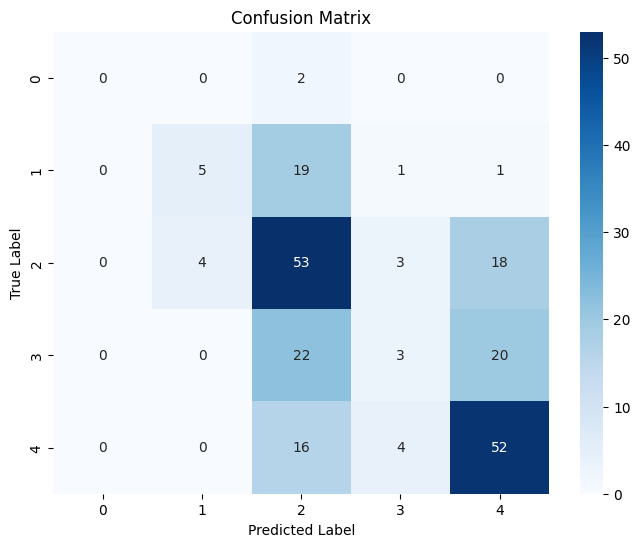

In [46]:
from sklearn.metrics import confusion_matrix

# Calcola la confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualizza con heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(c) for c in le.classes_],
            yticklabels=[str(c) for c in le.classes_])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


### Accesso alle shapelets

In [48]:
shapelets = shp_clf.shapelets_as_time_series_
for i, shapelet_group in enumerate(shapelets):
    print(f"Shapelets of length {shapelet_group.shape[1]}: {shapelet_group.shape[0]}")


Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30
Shapelets of length 1: 30


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sktime.transformations.panel.shapelets import ShapeletTransform
from sktime.classification.shapelet_based import ShapeletModel

# X_ts: dataset temporale (2D: n_samples x n_timestamps)
# y: target (numerico)

# 1. Standardizza i dati
scaler_ts = StandardScaler()
X_ts_scaled = scaler_ts.fit_transform(X_ts)

# 2. Reshape a 3D per sktime: (n_samples, n_timestamps, n_features)
X_ts_scaled = X_ts_scaled.reshape((X_ts_scaled.shape[0], X_ts_scaled.shape[1], 1))

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_ts_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 4. Crea e addestra il modello shapelet
shapelet_sizes = {20: 5, 30: 5, 40: 5}
shp_model = ShapeletModel(shapelet_sizes=shapelet_sizes, estimator=RandomForestClassifier(n_estimators=100), random_state=42)
shp_model.fit(X_train, y_train)

# 5. Predizione e valutazione
y_pred = shp_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# 6. Visualizza le shapelet apprese
shapelets = shp_model.shapelets_as_time_series_
for i, shapelet_group in enumerate(shapelets):
    print(f"Shapelets of length {shapelet_group.shape[1]}: {shapelet_group.shape[0]}")
    plt.figure(figsize=(10, 4))
    for j, shp in enumerate(shapelet_group):
        plt.plot(shp.ravel(), label=f'Shapelet {j+1}')
    plt.title(f"Shapelets of length {shapelet_group.shape[1]}")
    plt.legend()
    plt.show()


ModuleNotFoundError: No module named 'sktime.transformations.panel.shapelets'

In [53]:
!pip install sktime

  Using cached sktime-0.37.0-py3-none-any.whl.metadata (34 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.2.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (89 kB)
  Using cached scikit_base-0.12.3-py3-none-any.whl.metadata (8.8 kB)
  Using cached scikit_learn-1.6.1-cp310-cp310-macosx_12_0_arm64.whl.metadata (31 kB)
Using cached sktime-0.37.0-py3-none-any.whl (37.0 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached pandas-2.2.3-cp310-cp310-macosx_11_0_arm64.whl (11.3 MB)
Using cached scikit_base-0.12.3-py3-none-any.whl (145 kB)
Using cached scikit_learn-1.6.1-cp310-cp310-macosx_12_0_arm64.whl (11.1 MB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: scikit-learn━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [joblib]
    Found existing installation: scikit-learn 1.7.0━━━━━━━━━━━ 1/5 [joblib]
    Uninstalling scikit

=== AVVIO PIPELINE COMPLETA ===
Dataset caricato: (1112, 125)
Valori mancanti - TS: 0, Extra features: 0
Time series shape: (1112, 100)
Extra features shape: (1112, 22)
Classi target: [0 1 2 3 4]
Distribuzione classi: [ 10 128 387 226 361]
Ottimizzazione parametri shapelet...
l=0.05, r=3: score=0.4012
l=0.05, r=5: score=0.4042
l=0.05, r=7: score=0.3982
l=0.1, r=3: score=0.3862
l=0.1, r=5: score=0.4042
l=0.1, r=7: score=0.4072
l=0.15, r=3: score=0.4132
l=0.15, r=5: score=0.3892
Errore con l=0.15, r=7: cannot convert float NaN to integer...
l=0.2, r=3: score=0.4012
l=0.2, r=5: score=0.4222
Errore con l=0.2, r=7: cannot convert float NaN to integer...
Migliori parametri: {'l': 0.2, 'r': 5}, score: 0.4222
Shapelet sizes: {20: 5, 40: 5, 60: 5, 80: 4, 100: 3}
Numero totale shapelets: 22
Training shapelet model...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.1183 - categorical_crossentropy: 13.5555 - loss: 13.6378
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/ste

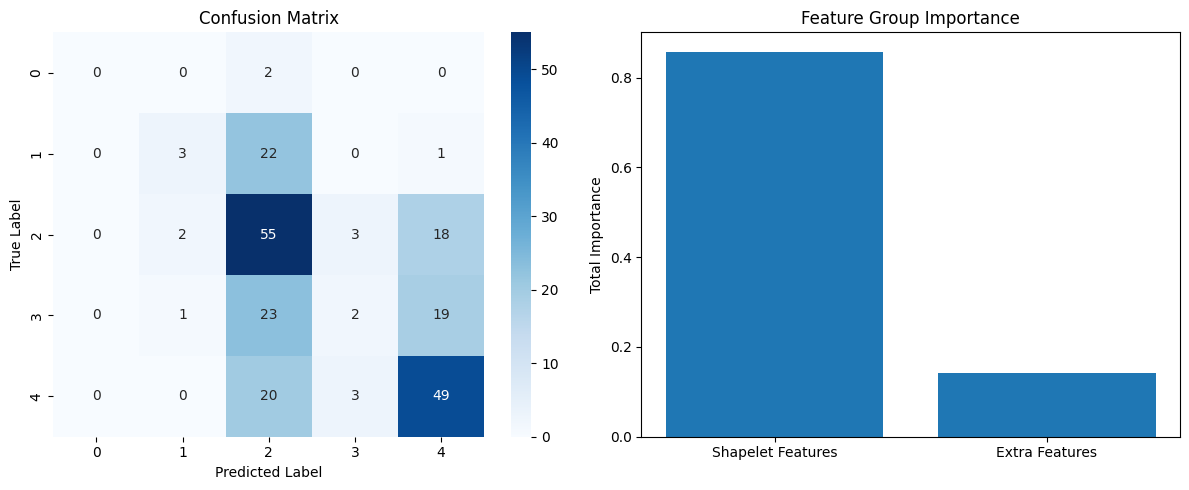


Analisi Shapelets:
Numero totale shapelets: 22


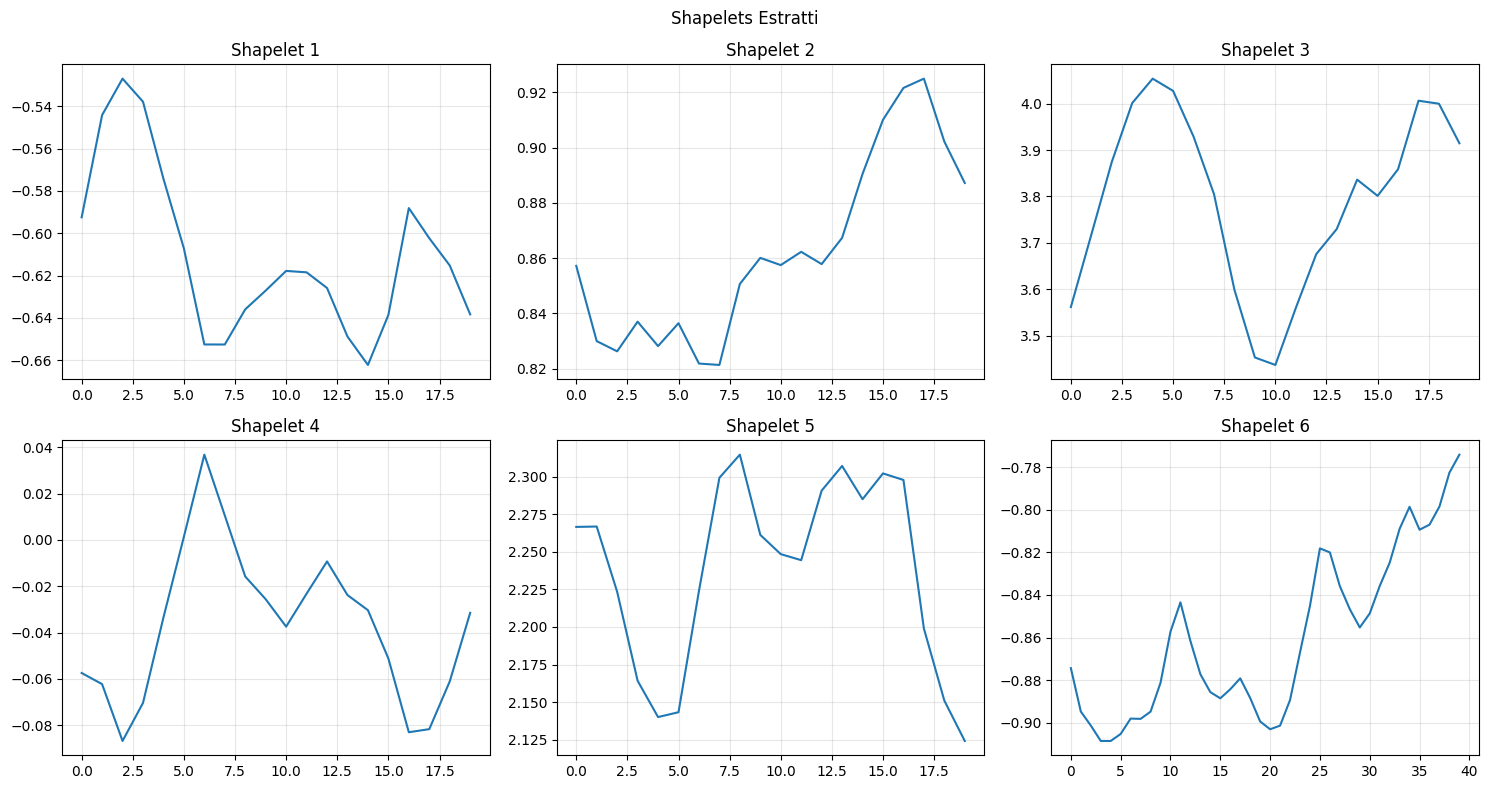


Accuracy finale: 0.4888


In [58]:
import numpy as np
import pandas as pd
from tslearn.shapelets import ShapeletModel, grabocka_params_to_shapelet_size_dict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

class TimeSeriesShapeletClassifier:
    def __init__(self, shapelet_l=0.1, shapelet_r=5, max_iter=100, random_state=42):
        """
        Classificatore time series basato su shapelets con features aggiuntive
        
        Parameters:
        -----------
        shapelet_l : float, lunghezza media shapelet come frazione della serie temporale
        shapelet_r : int, numero di shapelets per classe
        max_iter : int, iterazioni massime per il training degli shapelets
        random_state : int, seed per riproducibilità
        """
        self.shapelet_l = shapelet_l
        self.shapelet_r = shapelet_r
        self.max_iter = max_iter
        self.random_state = random_state
        
        # Inizializza componenti
        self.le = LabelEncoder()
        self.scaler_ts = StandardScaler()
        self.scaler_extra = StandardScaler()
        self.imputer_ts = SimpleImputer(strategy='mean')
        self.imputer_extra = SimpleImputer(strategy='mean')
        self.shapelet_model = None
        self.classifier = None
        
    def load_and_preprocess_data(self, filepath, ts_cols=(1, 101), extra_cols=(103, 126), target_col=102):
        """
        Carica e preprocessa i dati con gestione dei valori mancanti
        
        Parameters:
        -----------
        filepath : str, path del file CSV
        ts_cols : tuple, range colonne time series (start, end)
        extra_cols : tuple, range colonne features extra (start, end)  
        target_col : int, indice colonna target
        """
        try:
            self.df = pd.read_csv(filepath)
            print(f"Dataset caricato: {self.df.shape}")
            
            # Estrai dati
            self.X_ts = self.df.iloc[:, ts_cols[0]:ts_cols[1]].values
            self.X_extra = self.df.iloc[:, extra_cols[0]:extra_cols[1]].values
            self.y = self.df.iloc[:, target_col].values
            
            # Controlla e gestisci dati mancanti
            ts_missing = np.isnan(self.X_ts).sum()
            extra_missing = np.isnan(self.X_extra).sum()
            
            print(f"Valori mancanti - TS: {ts_missing}, Extra features: {extra_missing}")
            
            # Rimuovi righe con troppi valori mancanti nel target
            valid_target_mask = ~pd.isna(self.y)
            if not valid_target_mask.all():
                print(f"Rimosse {(~valid_target_mask).sum()} righe con target mancante")
                self.X_ts = self.X_ts[valid_target_mask]
                self.X_extra = self.X_extra[valid_target_mask]
                self.y = self.y[valid_target_mask]
            
            # Imputa valori mancanti nelle time series
            if ts_missing > 0:
                print("Imputazione valori mancanti in time series...")
                self.X_ts = self.imputer_ts.fit_transform(self.X_ts)
            
            # Imputa valori mancanti nelle features extra
            if extra_missing > 0:
                print("Imputazione valori mancanti in features extra...")
                self.X_extra = self.imputer_extra.fit_transform(self.X_extra)
            
            # Verifica che non ci siano più NaN
            if np.isnan(self.X_ts).any() or np.isnan(self.X_extra).any():
                raise ValueError("Ancora presenti valori NaN dopo l'imputazione")
            
            # Encoding target e scaling
            self.y_encoded = self.le.fit_transform(self.y)
            self.X_ts_scaled = self.scaler_ts.fit_transform(self.X_ts)
            
            print(f"Time series shape: {self.X_ts_scaled.shape}")
            print(f"Extra features shape: {self.X_extra.shape}")
            print(f"Classi target: {self.le.classes_}")
            print(f"Distribuzione classi: {np.bincount(self.y_encoded)}")
            
            # Verifica bilanciamento delle classi
            class_counts = np.bincount(self.y_encoded)
            min_samples = min(class_counts)
            if min_samples < 5:
                print(f"ATTENZIONE: Classe con pochi campioni ({min_samples}). Considera di rimuoverla o usare strategie di bilanciamento.")
            
        except Exception as e:
            print(f"Errore nel caricamento dati: {e}")
            raise
    
    def optimize_shapelet_params(self, param_grid=None):
        """
        Ottimizza parametri shapelet con grid search più robusto
        """
        if param_grid is None:
            param_grid = {
                'l': [0.05, 0.1, 0.15, 0.2],
                'r': [3, 5, 7]  # Ridotto per evitare problemi di memoria
            }
        
        best_score = -1
        best_params = None
        
        print("Ottimizzazione parametri shapelet...")
        
        # Split per validazione
        X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(
            self.X_ts_scaled, self.y_encoded, test_size=0.3, 
            stratify=self.y_encoded, random_state=self.random_state
        )
        
        for l in param_grid['l']:
            for r in param_grid['r']:
                try:
                    # Calcola shapelet sizes
                    shapelet_sizes = grabocka_params_to_shapelet_size_dict(
                        n_ts=X_train_val.shape[0],
                        ts_sz=X_train_val.shape[1],
                        n_classes=len(np.unique(y_train_val)),
                        l=l, r=r
                    )
                    
                    # Verifica che le dimensioni siano ragionevoli
                    total_shapelets = sum(shapelet_sizes.values())
                    if total_shapelets > 100:  # Limite per evitare problemi di memoria
                        print(f"l={l}, r={r}: troppi shapelets ({total_shapelets}), saltato")
                        continue
                    
                    # Crea e testa modello
                    shp_model = ShapeletModel(
                        n_shapelets_per_size=shapelet_sizes,
                        optimizer='adam',
                        weight_regularizer=0.01,
                        max_iter=30,  # Ridotto per grid search
                        random_state=self.random_state,
                        verbose=0
                    )
                    
                    shp_model.fit(X_train_val, y_train_val)
                    X_shp_train = shp_model.transform(X_train_val)
                    X_shp_test = shp_model.transform(X_test_val)
                    
                    # Verifica che non ci siano NaN nei risultati
                    if np.isnan(X_shp_train).any() or np.isnan(X_shp_test).any():
                        print(f"l={l}, r={r}: NaN nei risultati shapelet, saltato")
                        continue
                    
                    # Test rapido con RandomForest
                    rf_temp = RandomForestClassifier(n_estimators=50, random_state=self.random_state)
                    rf_temp.fit(X_shp_train, y_train_val)
                    score = rf_temp.score(X_shp_test, y_test_val)
                    
                    print(f"l={l}, r={r}: score={score:.4f}")
                    
                    if score > best_score:
                        best_score = score
                        best_params = {'l': l, 'r': r}
                
                except Exception as e:
                    print(f"Errore con l={l}, r={r}: {str(e)[:100]}...")
                    continue
        
        if best_params is None:
            print("Nessun parametro valido trovato, uso valori di default")
            best_params = {'l': 0.1, 'r': 3}
            best_score = 0.0
        
        print(f"Migliori parametri: {best_params}, score: {best_score:.4f}")
        self.shapelet_l = best_params['l']
        self.shapelet_r = best_params['r']
        
        return best_params, best_score
    
    def train_shapelet_model(self):
        """
        Addestra il modello shapelet con gestione errori migliorata
        """
        try:
            # Calcola shapelet sizes ottimali
            shapelet_sizes = grabocka_params_to_shapelet_size_dict(
                n_ts=self.X_ts_scaled.shape[0],
                ts_sz=self.X_ts_scaled.shape[1],
                n_classes=len(np.unique(self.y_encoded)),
                l=self.shapelet_l,
                r=self.shapelet_r
            )
            
            print(f"Shapelet sizes: {shapelet_sizes}")
            total_shapelets = sum(shapelet_sizes.values())
            print(f"Numero totale shapelets: {total_shapelets}")
            
            # Verifica dimensioni ragionevoli
            if total_shapelets > 150:
                print("Troppi shapelets, riduco il parametro r...")
                self.shapelet_r = max(2, self.shapelet_r - 2)
                shapelet_sizes = grabocka_params_to_shapelet_size_dict(
                    n_ts=self.X_ts_scaled.shape[0],
                    ts_sz=self.X_ts_scaled.shape[1],
                    n_classes=len(np.unique(self.y_encoded)),
                    l=self.shapelet_l,
                    r=self.shapelet_r
                )
                print(f"Shapelet sizes ridotte: {shapelet_sizes}")
            
            # Crea e addestra modello shapelet
            self.shapelet_model = ShapeletModel(
                n_shapelets_per_size=shapelet_sizes,
                optimizer='adam',
                weight_regularizer=0.01,
                max_iter=self.max_iter,
                random_state=self.random_state,
                verbose=1
            )
            
            print("Training shapelet model...")
            self.shapelet_model.fit(self.X_ts_scaled, self.y_encoded)
            
            # Trasforma i dati
            self.X_shp = self.shapelet_model.transform(self.X_ts_scaled)
            
            # Verifica risultati
            if np.isnan(self.X_shp).any():
                raise ValueError("NaN presenti nelle features shapelet")
            
            print(f"Shapelet features shape: {self.X_shp.shape}")
            
        except Exception as e:
            print(f"Errore nel training shapelet: {e}")
            print("Fallback: uso features time series medie come backup...")
            # Fallback: usa statistiche di base delle time series
            self.X_shp = np.column_stack([
                np.mean(self.X_ts_scaled, axis=1),
                np.std(self.X_ts_scaled, axis=1),
                np.min(self.X_ts_scaled, axis=1),
                np.max(self.X_ts_scaled, axis=1),
                np.median(self.X_ts_scaled, axis=1)
            ])
            print(f"Backup features shape: {self.X_shp.shape}")
    
    def prepare_combined_features(self):
        """
        Combina features shapelet con features extra
        """
        # Scala features extra
        self.X_extra_scaled = self.scaler_extra.fit_transform(self.X_extra)
        
        # Verifica che non ci siano NaN
        if np.isnan(self.X_extra_scaled).any():
            raise ValueError("NaN presenti nelle features extra scalate")
        
        # Combina features
        self.X_combined = np.hstack([self.X_shp, self.X_extra_scaled])
        print(f"Combined features shape: {self.X_combined.shape}")
        
        # Verifica finale
        if np.isnan(self.X_combined).any():
            raise ValueError("NaN presenti nelle features combinate")
        
        return self.X_combined
    
    def optimize_classifier(self):
        """
        Ottimizza iperparametri del classificatore finale
        """
        # Split train/test
        X_train, X_test, y_train, y_test = train_test_split(
            self.X_combined, self.y_encoded, test_size=0.2, 
            stratify=self.y_encoded, random_state=self.random_state
        )
        
        # Grid search più semplice per evitare problemi
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt', 'log2']
        }
        
        print("Ottimizzazione classificatore...")
        rf = RandomForestClassifier(random_state=self.random_state, n_jobs=-1)
        
        # Usa GridSearchCV con cross-validation
        grid_search = GridSearchCV(
            rf, param_grid, cv=3, scoring='accuracy',  # Ridotto cv per velocità
            n_jobs=1, verbose=1  # n_jobs=1 per evitare conflitti
        )
        
        grid_search.fit(X_train, y_train)
        
        self.classifier = grid_search.best_estimator_
        print(f"Migliori parametri RF: {grid_search.best_params_}")
        print(f"Best CV score: {grid_search.best_score_:.4f}")
        
        return X_train, X_test, y_train, y_test
    
    def evaluate_model(self, X_test, y_test):
        """
        Valuta le performance del modello
        """
        # Predizioni
        y_pred = self.classifier.predict(X_test)
        
        # Metriche
        accuracy = accuracy_score(y_test, y_pred)
        print(f"\n=== RISULTATI FINALI ===")
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=[str(c) for c in self.le.classes_], zero_division=0))
        
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(12, 5))
        
        # Plot 1: Confusion Matrix
        plt.subplot(1, 2, 1)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=[str(c) for c in self.le.classes_], 
                   yticklabels=[str(c) for c in self.le.classes_])
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        
        # Plot 2: Feature Importance (se disponibile)
        if hasattr(self.classifier, 'feature_importances_'):
            plt.subplot(1, 2, 2)
            n_shapelet_features = self.X_shp.shape[1]
            n_extra_features = self.X_extra_scaled.shape[1]
            
            # Raggruppa importanze
            shapelet_importance = self.classifier.feature_importances_[:n_shapelet_features].sum()
            extra_importance = self.classifier.feature_importances_[n_shapelet_features:].sum()
            
            plt.bar(['Shapelet Features', 'Extra Features'], 
                   [shapelet_importance, extra_importance])
            plt.title('Feature Group Importance')
            plt.ylabel('Total Importance')
        
        plt.tight_layout()
        plt.show()
        
        return accuracy, y_pred
    
    def analyze_shapelets(self):
        """
        Analizza gli shapelets estratti (se disponibili)
        """
        if self.shapelet_model is None:
            print("Modello shapelet non disponibile!")
            return
        
        try:
            # Estrai shapelets
            shapelets = self.shapelet_model.shapelets_
            
            print(f"\nAnalisi Shapelets:")
            print(f"Numero totale shapelets: {len(shapelets)}")
            
            # Plot alcuni shapelets rappresentativi
            n_plots = min(6, len(shapelets))
            fig, axes = plt.subplots(2, 3, figsize=(15, 8))
            axes = axes.flatten()
            
            for i in range(n_plots):
                if i < len(shapelets):
                    axes[i].plot(shapelets[i])
                    axes[i].set_title(f'Shapelet {i+1}')
                    axes[i].grid(True, alpha=0.3)
                else:
                    axes[i].axis('off')
            
            plt.suptitle('Shapelets Estratti')
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Errore nell'analisi shapelets: {e}")
    
    def run_complete_pipeline(self, filepath, optimize_params=True):
        """
        Esegue l'intera pipeline con gestione errori robusta
        """
        print("=== AVVIO PIPELINE COMPLETA ===")
        
        try:
            # 1. Carica dati
            self.load_and_preprocess_data(filepath)
            
            # 2. Ottimizza parametri shapelet (opzionale)
            if optimize_params:
                self.optimize_shapelet_params()
            
            # 3. Addestra shapelet model
            self.train_shapelet_model()
            
            # 4. Prepara features combinate
            self.prepare_combined_features()
            
            # 5. Ottimizza classificatore
            X_train, X_test, y_train, y_test = self.optimize_classifier()
            
            # 6. Valuta modello
            accuracy, y_pred = self.evaluate_model(X_test, y_test)
            
            # 7. Analizza shapelets
            self.analyze_shapelets()
            
            return accuracy
            
        except Exception as e:
            print(f"Errore nella pipeline: {e}")
            print("Tentativo con versione semplificata...")
            return self.run_simple_pipeline(filepath)
    
    def run_simple_pipeline(self, filepath):
        """
        Pipeline semplificata senza ottimizzazione come fallback
        """
        print("=== PIPELINE SEMPLIFICATA ===")
        
        # Carica e preprocessa dati
        self.load_and_preprocess_data(filepath)
        
        # Usa parametri di default semplici
        self.shapelet_l = 0.1
        self.shapelet_r = 3
        
        # Training semplice
        self.train_shapelet_model()
        self.prepare_combined_features()
        
        # Split semplice
        X_train, X_test, y_train, y_test = train_test_split(
            self.X_combined, self.y_encoded, test_size=0.2, 
            stratify=self.y_encoded, random_state=self.random_state
        )
        
        # Classificatore con parametri fissi
        self.classifier = RandomForestClassifier(
            n_estimators=100, max_depth=20, random_state=self.random_state
        )
        self.classifier.fit(X_train, y_train)
        
        # Valutazione
        accuracy, y_pred = self.evaluate_model(X_test, y_test)
        
        return accuracy

# Esempio di utilizzo
if __name__ == "__main__":
    # Inizializza classificatore
    classifier = TimeSeriesShapeletClassifier(
        shapelet_l=0.1,
        shapelet_r=5,
        max_iter=100,
        random_state=42
    )
    
    # Esegui pipeline completa
    filepath = '/Users/chiaracap/Downloads/06_TS_Understanding/TS_NO_OUTLIERS.csv'
    
    try:
        final_accuracy = classifier.run_complete_pipeline(
            filepath, 
            optimize_params=True  # Cambia a False per saltare l'ottimizzazione
        )
        print(f"\nAccuracy finale: {final_accuracy:.4f}")
        
    except Exception as e:
        print(f"Errore nell'esecuzione: {e}")

# Versione ultra-semplice per debug
def debug_quick_check(filepath):
    """
    Verifica rapida dei dati e gestione NaN
    """
    print("=== DEBUG QUICK CHECK ===")
    
    try:
        df = pd.read_csv(filepath)
        print(f"Dataset shape: {df.shape}")
        
        # Controlla NaN
        nan_count = df.isnull().sum().sum()
        print(f"Totale valori NaN: {nan_count}")
        
        if nan_count > 0:
            print("Colonne con NaN:")
            nan_cols = df.isnull().sum()
            print(nan_cols[nan_cols > 0])
        
        # Controlla target
        target_col = df.iloc[:, 102]
        print(f"Target unique values: {target_col.unique()}")
        print(f"Target NaN: {target_col.isnull().sum()}")
        print(f"Target distribution: {target_col.value_counts()}")
        
        return True
        
    except Exception as e:
        print(f"Errore nel debug: {e}")
        return False

Modulo di analisi shapelets caricato!
Usa analyze_existing_classifier(your_classifier) per analizzare un classificatore esistente
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Estratti 22 shapelets con lunghezze: {100, 40, 80, 20, 60}
=== ANALISI COMPLETA SHAPELETS ===

1. Overview Shapelets...


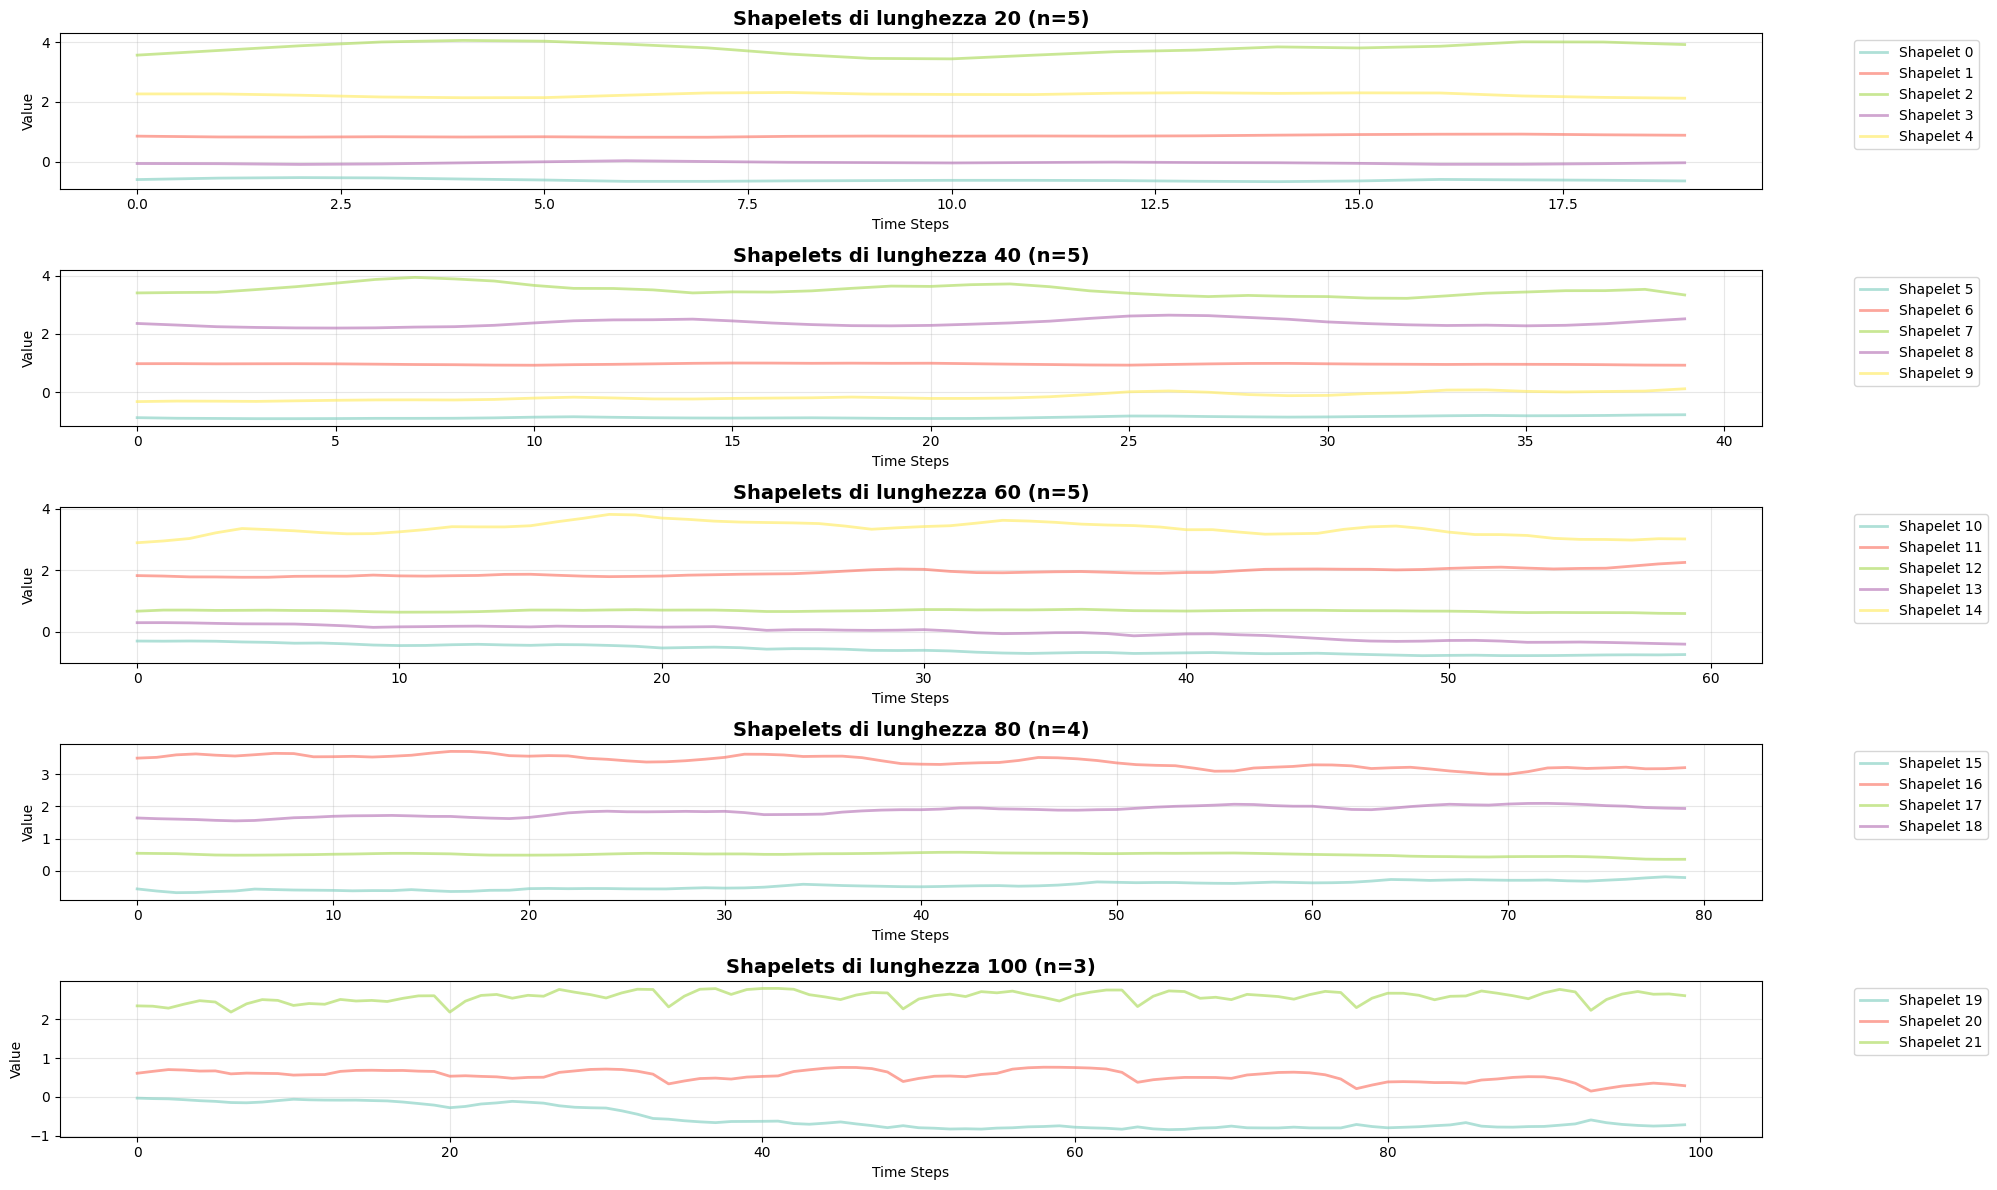


2. Analisi Statistiche...


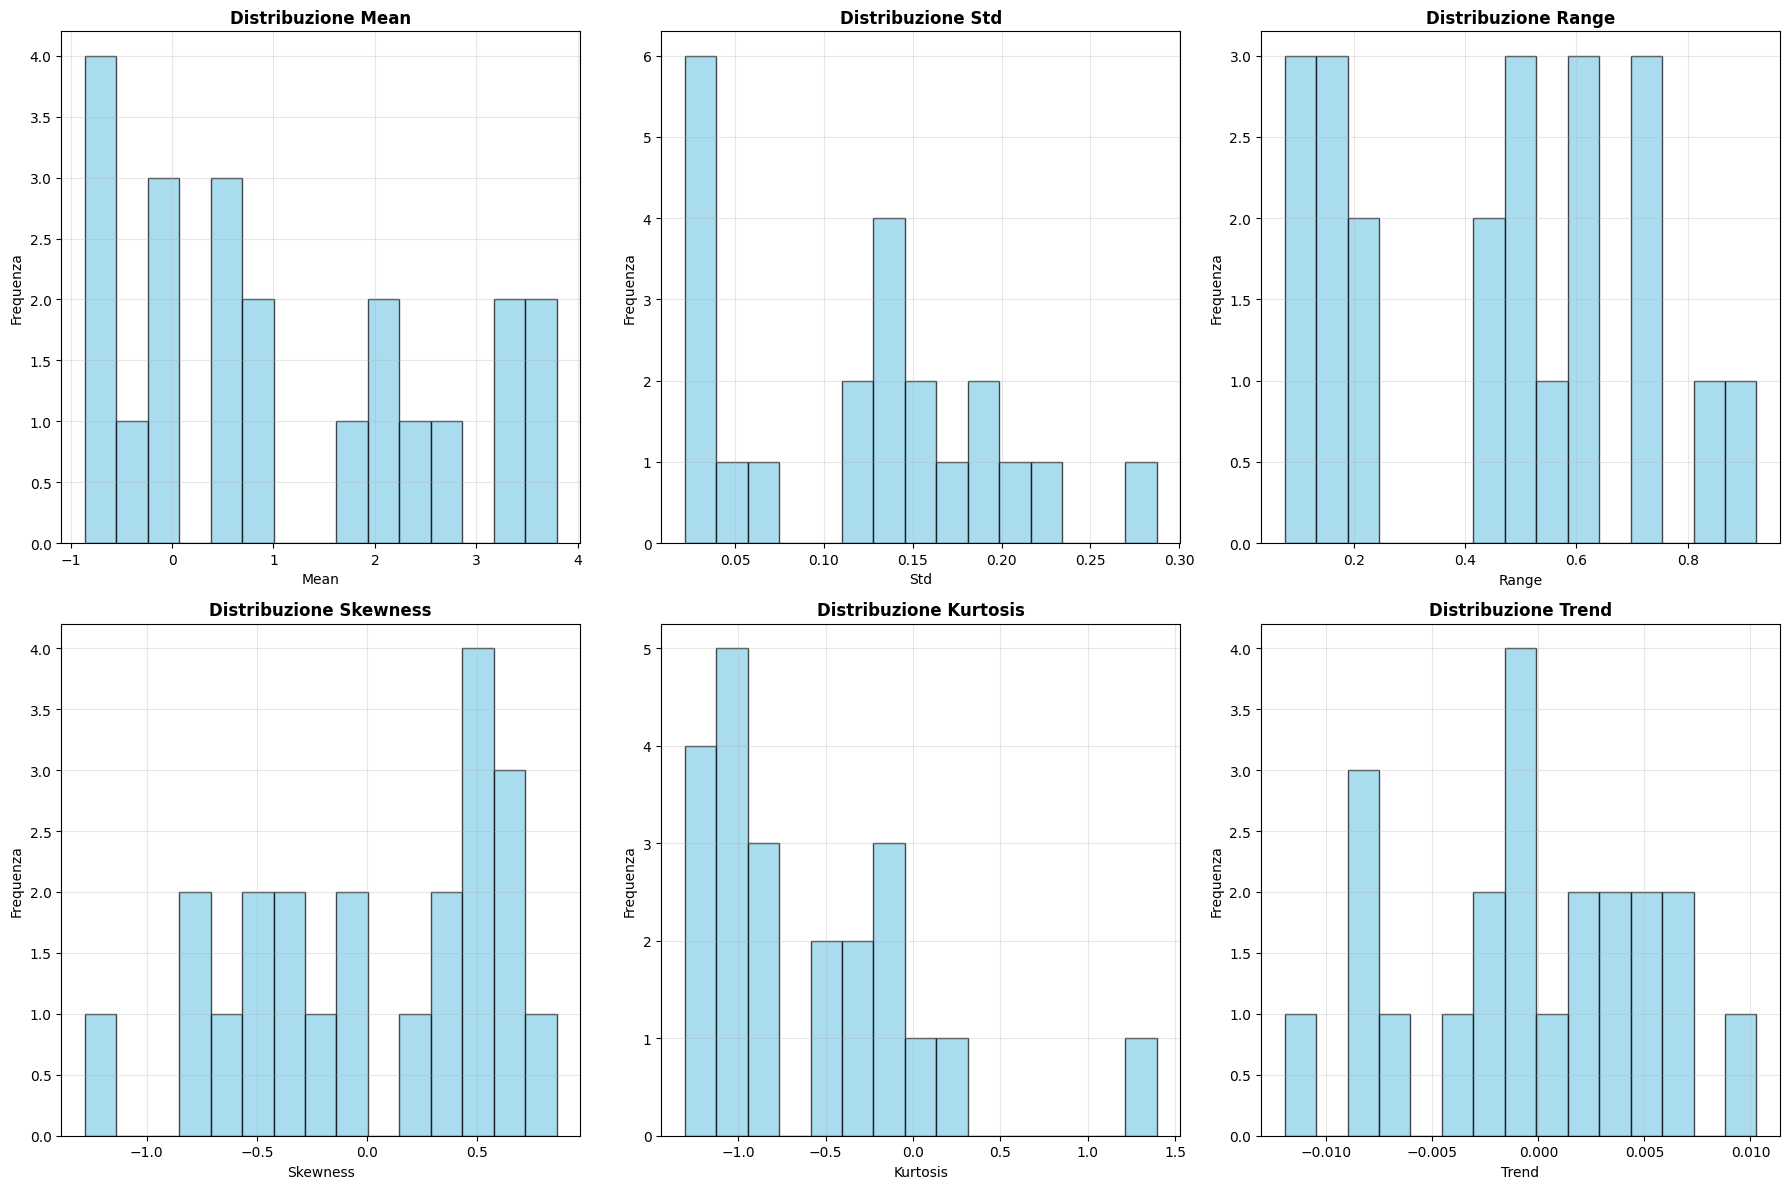

Statistiche Shapelets:
       Shapelet_ID    Length     Mean      Std      Min      Max    Range  \
count      22.0000   22.0000  22.0000  22.0000  22.0000  22.0000  22.0000   
mean       10.5000   55.4545   1.1508   0.1212   0.9330   1.3745   0.4415   
std         6.4936   27.5555   1.5345   0.0746   1.4711   1.5852   0.2614   
min         0.0000   20.0000  -0.8600   0.0217  -0.9085  -0.7741   0.0756   
25%         5.2500   40.0000  -0.1162   0.0412  -0.3851   0.0566   0.1515   
50%        10.5000   60.0000   0.7707   0.1285   0.7069   0.8449   0.4801   
75%        15.7500   80.0000   2.3389   0.1738   2.1722   2.5596   0.6167   
max        21.0000  100.0000   3.7921   0.2872   3.4371   4.0538   0.9236   

       Skewness  Kurtosis    Trend  
count   22.0000   22.0000  22.0000  
mean     0.0085   -0.6088  -0.0005  
std      0.5960    0.6414   0.0058  
min     -1.2807   -1.3069  -0.0120  
25%     -0.4213   -1.0996  -0.0035  
50%      0.0610   -0.8306  -0.0005  
75%      0.5667   -0.221

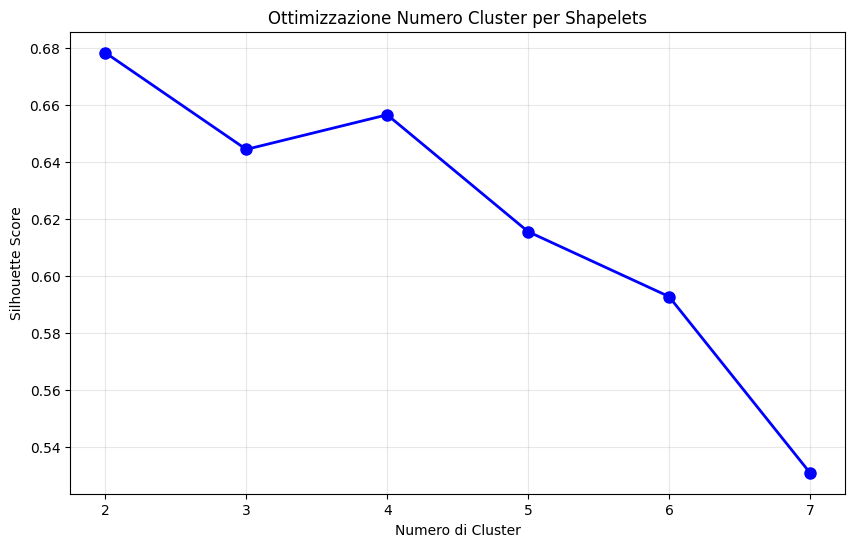

Numero ottimale di cluster: 2


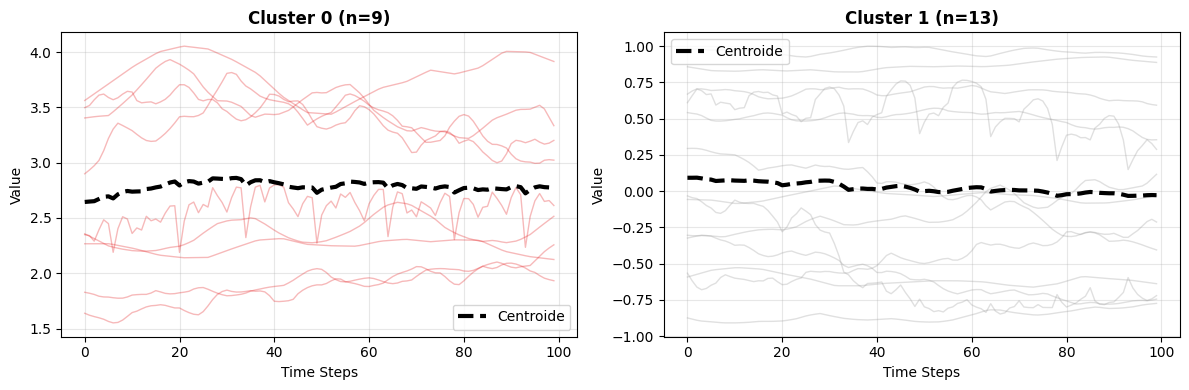


4. Analisi Discriminazione Classi...


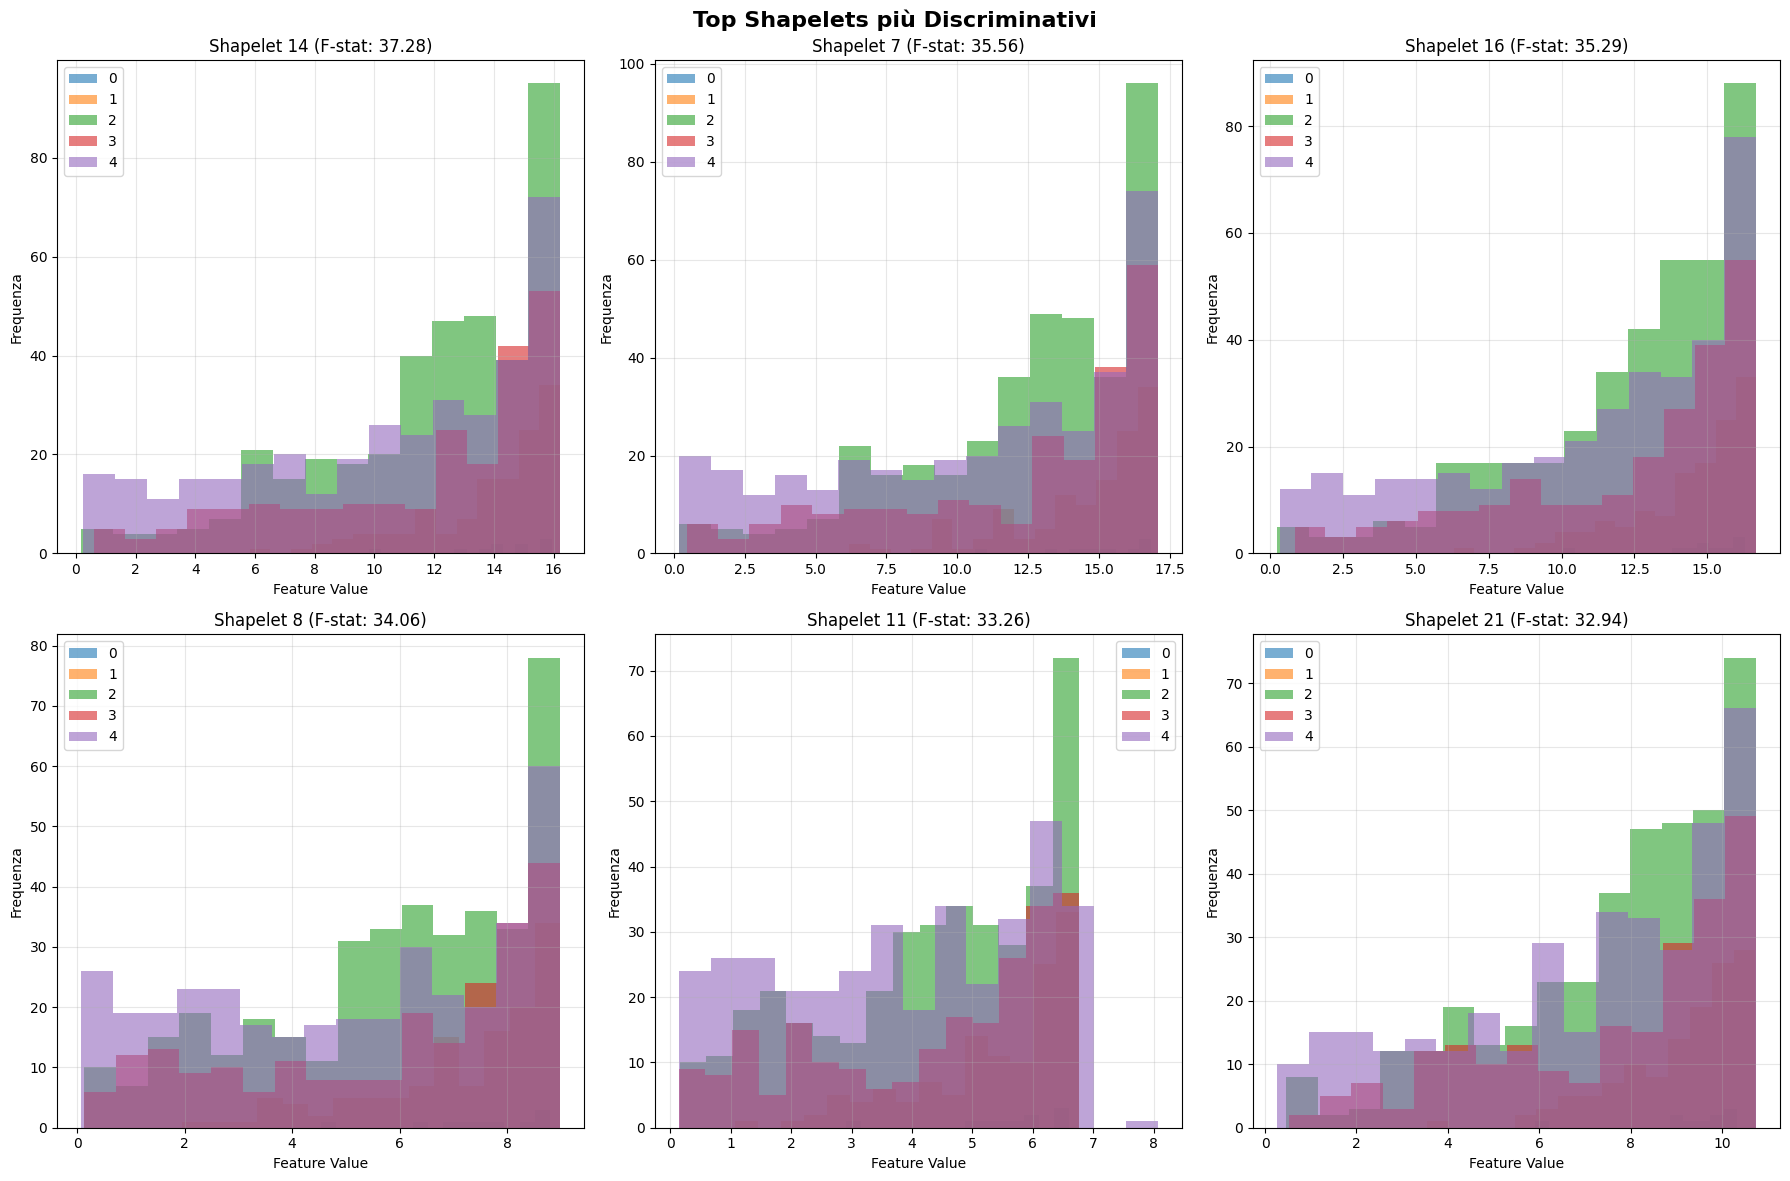


5. Analisi Correlazioni...


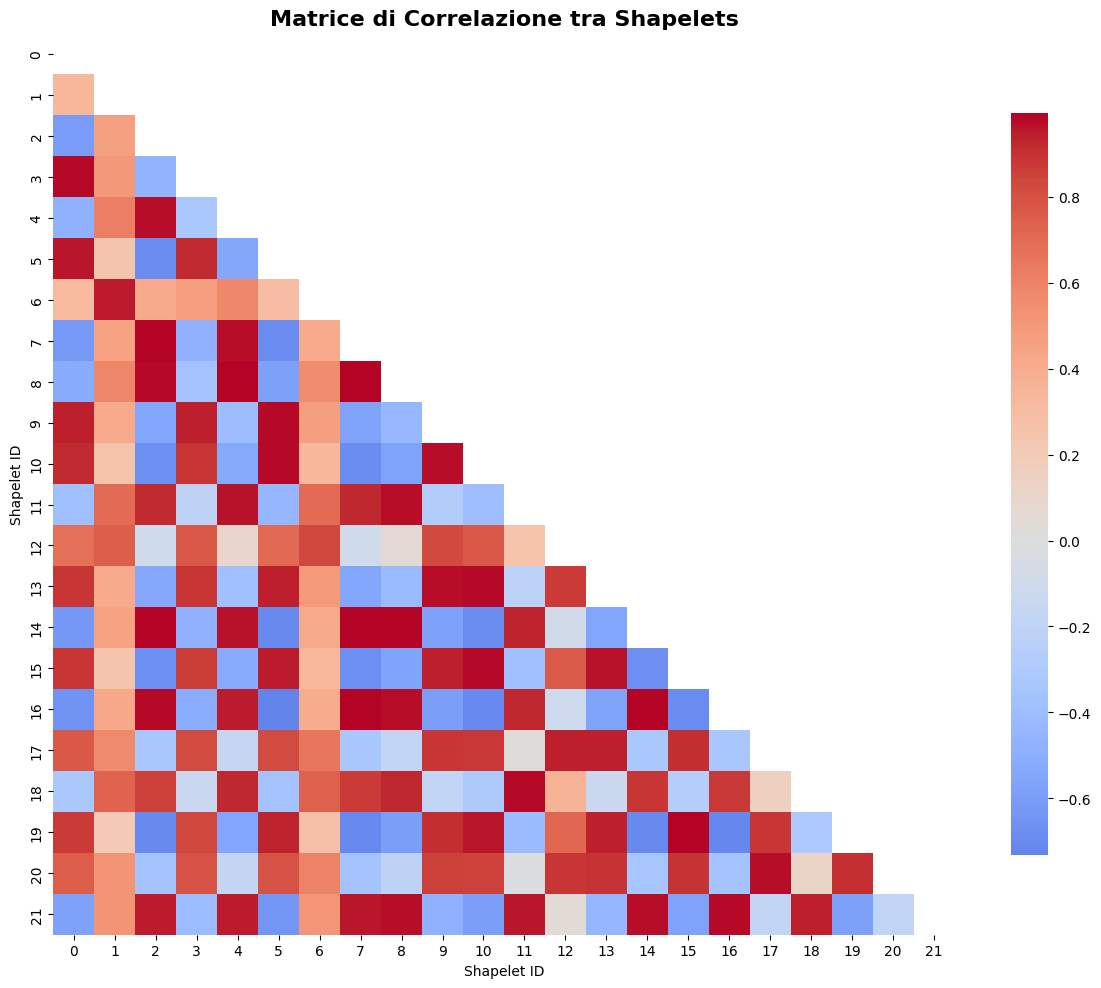

Coppie di Shapelets altamente correlate (|r| > 0.7):
Shapelet 0 - Shapelet 3: r = 0.978
Shapelet 0 - Shapelet 5: r = 0.957
Shapelet 0 - Shapelet 9: r = 0.946
Shapelet 0 - Shapelet 10: r = 0.917
Shapelet 0 - Shapelet 13: r = 0.886
Shapelet 0 - Shapelet 15: r = 0.892
Shapelet 0 - Shapelet 17: r = 0.768
Shapelet 0 - Shapelet 19: r = 0.872
Shapelet 0 - Shapelet 20: r = 0.759
Shapelet 1 - Shapelet 6: r = 0.954
Shapelet 1 - Shapelet 11: r = 0.700
Shapelet 1 - Shapelet 12: r = 0.751
Shapelet 1 - Shapelet 18: r = 0.730
Shapelet 2 - Shapelet 4: r = 0.975
Shapelet 2 - Shapelet 7: r = 0.995
Shapelet 2 - Shapelet 8: r = 0.979
Shapelet 2 - Shapelet 11: r = 0.917
Shapelet 2 - Shapelet 14: r = 0.987
Shapelet 2 - Shapelet 16: r = 0.977
Shapelet 2 - Shapelet 18: r = 0.858
Shapelet 2 - Shapelet 19: r = -0.702
Shapelet 2 - Shapelet 21: r = 0.949
Shapelet 3 - Shapelet 5: r = 0.917
Shapelet 3 - Shapelet 9: r = 0.945
Shapelet 3 - Shapelet 10: r = 0.886
Shapelet 3 - Shapelet 12: r = 0.768
Shapelet 3 - Shapel

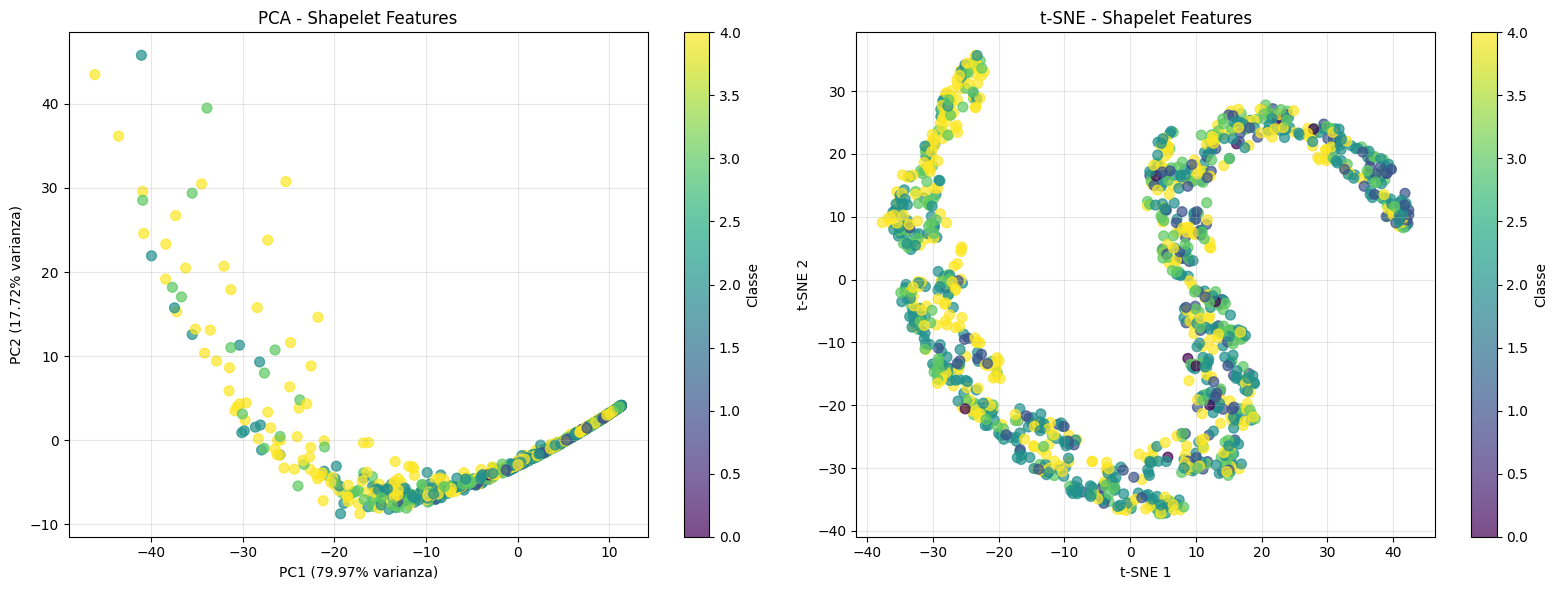


=== RIEPILOGO ANALISI ===
• Numero totale shapelets: 22
• Lunghezze shapelets: {100, 40, 80, 20, 60}
• Cluster ottimali: 2
• Miglior shapelet discriminativo: 14 (F-stat: 37.28)
• Varianza spiegata PCA (PC1+PC2): 97.69%


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

class ShapeletAnalyzer:
    def __init__(self, shapelet_model, X_ts_scaled, y_encoded, class_names=None):
        """
        Analizzatore avanzato per shapelets
        
        Parameters:
        -----------
        shapelet_model : ShapeletModel, modello shapelet addestrato
        X_ts_scaled : array, time series scalate originali
        y_encoded : array, target encoded
        class_names : list/array, nomi delle classi (opzionale)
        """
        self.shapelet_model = shapelet_model
        self.X_ts_scaled = X_ts_scaled
        self.y_encoded = y_encoded
        
        # Fix per il problema con class_names
        if class_names is not None:
            if isinstance(class_names, np.ndarray):
                self.class_names = class_names.tolist()
            else:
                self.class_names = list(class_names)
        else:
            self.class_names = [f"Class_{i}" for i in np.unique(y_encoded)]
        
        # Estrai shapelets e informazioni
        try:
            self.shapelets = shapelet_model.shapelets_
            
            # Fix per shapelets che potrebbero essere 2D
            processed_shapelets = []
            for shapelet in self.shapelets:
                if isinstance(shapelet, np.ndarray):
                    if shapelet.ndim == 2:
                        # Se è 2D, prendi la prima colonna o appiattisci
                        if shapelet.shape[1] == 1:
                            shapelet = shapelet.flatten()
                        else:
                            shapelet = shapelet.ravel()
                    elif shapelet.ndim > 2:
                        shapelet = shapelet.ravel()
                processed_shapelets.append(shapelet)
            
            self.shapelets = processed_shapelets
            self.shapelet_lengths = [len(s) for s in self.shapelets]
            self.n_shapelets = len(self.shapelets)
            self.shapelet_features = shapelet_model.transform(X_ts_scaled)
            print(f"Estratti {self.n_shapelets} shapelets con lunghezze: {set(self.shapelet_lengths)}")
        except Exception as e:
            print(f"Errore nell'estrazione shapelets: {e}")
            self.shapelets = None
    
    def plot_shapelets_overview(self, figsize=(20, 12)):
        """
        Vista d'insieme di tutti gli shapelets
        """
        if self.shapelets is None:
            print("Shapelets non disponibili!")
            return
        
        # Organizza shapelets per lunghezza
        shapelet_by_length = {}
        for i, shapelet in enumerate(self.shapelets):
            length = len(shapelet)
            if length not in shapelet_by_length:
                shapelet_by_length[length] = []
            shapelet_by_length[length].append((i, shapelet))
        
        n_length_groups = len(shapelet_by_length)
        fig, axes = plt.subplots(n_length_groups, 1, figsize=figsize)
        if n_length_groups == 1:
            axes = [axes]
        
        colors = plt.cm.Set3(np.linspace(0, 1, max(len(v) for v in shapelet_by_length.values())))
        
        for idx, (length, shapelets_group) in enumerate(shapelet_by_length.items()):
            ax = axes[idx]
            
            for i, (shapelet_idx, shapelet) in enumerate(shapelets_group):
                ax.plot(shapelet, color=colors[i % len(colors)], 
                       alpha=0.7, linewidth=2, label=f'Shapelet {shapelet_idx}')
            
            ax.set_title(f'Shapelets di lunghezza {length} (n={len(shapelets_group)})', 
                        fontsize=14, fontweight='bold')
            ax.set_xlabel('Time Steps')
            ax.set_ylabel('Value')
            ax.grid(True, alpha=0.3)
            
            # Mostra legend solo se non troppi shapelets
            if len(shapelets_group) <= 10:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.show()
    
    def analyze_shapelet_statistics(self):
        """
        Analisi statistiche dettagliate degli shapelets
        """
        if self.shapelets is None:
            return None
        
        stats_data = []
        for i, shapelet in enumerate(self.shapelets):
            # Assicurati che shapelet sia 1D
            if isinstance(shapelet, np.ndarray) and shapelet.ndim > 1:
                shapelet = shapelet.flatten()
            
            try:
                stats = {
                    'Shapelet_ID': i,
                    'Length': len(shapelet),
                    'Mean': np.mean(shapelet),
                    'Std': np.std(shapelet),
                    'Min': np.min(shapelet),
                    'Max': np.max(shapelet),
                    'Range': np.max(shapelet) - np.min(shapelet),
                    'Skewness': pd.Series(shapelet.flatten()).skew(),
                    'Kurtosis': pd.Series(shapelet.flatten()).kurtosis(),
                    'Trend': np.polyfit(range(len(shapelet)), shapelet.flatten(), 1)[0]  # Coefficiente angolare
                }
                stats_data.append(stats)
            except Exception as e:
                print(f"Errore nel processare shapelet {i}: {e}")
                continue
        
        if not stats_data:
            print("Nessuna statistica calcolabile")
            return None
        
        self.shapelet_stats = pd.DataFrame(stats_data)
        
        # Visualizzazione statistiche
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        metrics = ['Mean', 'Std', 'Range', 'Skewness', 'Kurtosis', 'Trend']
        
        for i, metric in enumerate(metrics):
            if metric in self.shapelet_stats.columns:
                axes[i].hist(self.shapelet_stats[metric], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
                axes[i].set_title(f'Distribuzione {metric}', fontweight='bold')
                axes[i].set_xlabel(metric)
                axes[i].set_ylabel('Frequenza')
                axes[i].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("Statistiche Shapelets:")
        print(self.shapelet_stats.describe().round(4))
        
        return self.shapelet_stats
    
    def shapelet_clustering_analysis(self, n_clusters_range=(2, 8)):
        """
        Analisi di clustering degli shapelets
        """
        if self.shapelets is None:
            return None, None
        
        if len(self.shapelets) < 2:
            print("Troppo pochi shapelets per il clustering")
            return None, None
        
        # Normalizza shapelets per il clustering (tutti alla stessa lunghezza)
        max_length = max(self.shapelet_lengths)
        shapelets_normalized = []
        
        for shapelet in self.shapelets:
            if len(shapelet) < max_length:
                # Interpola per portare alla lunghezza massima
                x_old = np.linspace(0, 1, len(shapelet))
                x_new = np.linspace(0, 1, max_length)
                shapelet_interp = np.interp(x_new, x_old, shapelet)
                shapelets_normalized.append(shapelet_interp)
            else:
                shapelets_normalized.append(shapelet)
        
        X_shapelets = np.array(shapelets_normalized)
        
        # Trova numero ottimale di cluster
        silhouette_scores = []
        max_clusters = min(n_clusters_range[1], len(self.shapelets))
        K_range = range(n_clusters_range[0], max_clusters)
        
        for k in K_range:
            if k < len(self.shapelets):
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                cluster_labels = kmeans.fit_predict(X_shapelets)
                score = silhouette_score(X_shapelets, cluster_labels)
                silhouette_scores.append(score)
        
        if not silhouette_scores:
            print("Impossibile calcolare clustering")
            return None, None
        
        # Plot silhouette scores
        plt.figure(figsize=(10, 6))
        plt.plot(K_range[:len(silhouette_scores)], silhouette_scores, 'bo-', linewidth=2, markersize=8)
        plt.xlabel('Numero di Cluster')
        plt.ylabel('Silhouette Score')
        plt.title('Ottimizzazione Numero Cluster per Shapelets')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Usa il miglior numero di cluster
        best_k = K_range[np.argmax(silhouette_scores)]
        print(f"Numero ottimale di cluster: {best_k}")
        
        # Clustering finale
        kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        self.shapelet_clusters = kmeans_best.fit_predict(X_shapelets)
        
        # Visualizza cluster
        self.plot_shapelet_clusters(X_shapelets, self.shapelet_clusters, best_k)
        
        return self.shapelet_clusters, best_k
    
    def plot_shapelet_clusters(self, X_shapelets, cluster_labels, n_clusters):
        """
        Visualizza i cluster di shapelets
        """
        n_cols = min(3, n_clusters)
        n_rows = (n_clusters + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes
        else:
            axes = axes.flatten()
        
        colors = plt.cm.Set1(np.linspace(0, 1, n_clusters))
        
        for cluster_id in range(n_clusters):
            cluster_shapelets = X_shapelets[cluster_labels == cluster_id]
            ax = axes[cluster_id]
            
            # Plot tutti gli shapelets del cluster
            for shapelet in cluster_shapelets:
                ax.plot(shapelet, color=colors[cluster_id], alpha=0.3, linewidth=1)
            
            # Plot centroide
            centroid = np.mean(cluster_shapelets, axis=0)
            ax.plot(centroid, color='black', linewidth=3, linestyle='--', label='Centroide')
            
            ax.set_title(f'Cluster {cluster_id} (n={len(cluster_shapelets)})', fontweight='bold')
            ax.set_xlabel('Time Steps')
            ax.set_ylabel('Value')
            ax.grid(True, alpha=0.3)
            ax.legend()
        
        # Rimuovi assi extra
        for i in range(n_clusters, len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def shapelet_class_discrimination(self):
        """
        Analizza quanto bene ogni shapelet discrimina tra le classi
        """
        if self.shapelet_features is None:
            return None, None
        
        discrimination_scores = []
        
        for i in range(self.shapelet_features.shape[1]):
            feature = self.shapelet_features[:, i]
            
            # Calcola separabilità tra classi (usando ANOVA F-statistic)
            class_means = []
            class_vars = []
            
            for class_id in np.unique(self.y_encoded):
                class_data = feature[self.y_encoded == class_id]
                if len(class_data) > 0:
                    class_means.append(np.mean(class_data))
                    class_vars.append(np.var(class_data))
            
            if len(class_means) > 1:
                # F-statistic approssimativo
                between_var = np.var(class_means) * len(feature) / len(class_means)
                within_var = np.mean(class_vars)
                
                f_stat = between_var / (within_var + 1e-10)  # Evita divisione per zero
                discrimination_scores.append(f_stat)
            else:
                discrimination_scores.append(0)
        
        # Ordina shapelets per capacità discriminativa
        sorted_indices = np.argsort(discrimination_scores)[::-1]
        
        # Plot top shapelets discriminativi
        n_plots = min(6, len(sorted_indices))
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        for i in range(n_plots):
            shapelet_idx = sorted_indices[i]
            ax = axes[i]
            
            # Plot distribuzione feature per classe
            for class_id in np.unique(self.y_encoded):
                class_data = self.shapelet_features[self.y_encoded == class_id, shapelet_idx]
                class_name = self.class_names[class_id] if class_id < len(self.class_names) else f"Class_{class_id}"
                ax.hist(class_data, alpha=0.6, label=class_name, bins=15)
            
            ax.set_title(f'Shapelet {shapelet_idx} (F-stat: {discrimination_scores[shapelet_idx]:.2f})')
            ax.set_xlabel('Feature Value')
            ax.set_ylabel('Frequenza')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # Rimuovi subplot extra
        for i in range(n_plots, len(axes)):
            axes[i].axis('off')
        
        plt.suptitle('Top Shapelets più Discriminativi', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        return discrimination_scores, sorted_indices
    
    def shapelet_correlation_heatmap(self):
        """
        Heatmap delle correlazioni tra shapelets
        """
        if self.shapelet_features is None:
            return None
        
        # Calcola matrice di correlazione
        corr_matrix = np.corrcoef(self.shapelet_features.T)
        
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        
        sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
                   square=True, fmt='.2f', cbar_kws={"shrink": .8})
        
        plt.title('Matrice di Correlazione tra Shapelets', fontsize=16, fontweight='bold')
        plt.xlabel('Shapelet ID')
        plt.ylabel('Shapelet ID')
        plt.tight_layout()
        plt.show()
        
        # Trova coppie più correlate
        upper_tri = np.triu(corr_matrix, k=1)
        high_corr_pairs = np.where(np.abs(upper_tri) > 0.7)
        
        if len(high_corr_pairs[0]) > 0:
            print("Coppie di Shapelets altamente correlate (|r| > 0.7):")
            for i, j in zip(high_corr_pairs[0], high_corr_pairs[1]):
                print(f"Shapelet {i} - Shapelet {j}: r = {corr_matrix[i,j]:.3f}")
        else:
            print("Nessuna coppia di shapelets altamente correlata trovata")
        
        return corr_matrix
    
    def dimensional_reduction_analysis(self):
        """
        Analisi di riduzione dimensionale delle features shapelet
        """
        if self.shapelet_features is None:
            return None, None
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(self.shapelet_features)
        
        scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=self.y_encoded, 
                                cmap='viridis', alpha=0.7, s=50)
        axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
        axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
        axes[0].set_title('PCA - Shapelet Features')
        axes[0].grid(True, alpha=0.3)
        
        # Aggiungi colorbar
        cbar = plt.colorbar(scatter, ax=axes[0])
        cbar.set_label('Classe')
        
        # t-SNE
        if self.shapelet_features.shape[0] > 5:  # t-SNE richiede almeno qualche campione
            perplexity = min(30, max(5, len(self.shapelet_features)//4))
            tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
            X_tsne = tsne.fit_transform(self.shapelet_features)
            
            scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=self.y_encoded, 
                                     cmap='viridis', alpha=0.7, s=50)
            axes[1].set_xlabel('t-SNE 1')
            axes[1].set_ylabel('t-SNE 2')
            axes[1].set_title('t-SNE - Shapelet Features')
            axes[1].grid(True, alpha=0.3)
            
            cbar2 = plt.colorbar(scatter2, ax=axes[1])
            cbar2.set_label('Classe')
        else:
            axes[1].text(0.5, 0.5, 'Troppo pochi campioni\nper t-SNE', 
                        ha='center', va='center', transform=axes[1].transAxes)
            axes[1].set_title('t-SNE - Non disponibile')
        
        plt.tight_layout()
        plt.show()
        
        return X_pca, pca.explained_variance_ratio_
    
    def run_complete_analysis(self):
        """
        Esegue tutte le analisi
        """
        print("=== ANALISI COMPLETA SHAPELETS ===\n")
        
        if self.shapelets is None:
            print("Impossibile procedere: shapelets non disponibili")
            return
        
        # 1. Overview shapelets
        print("1. Overview Shapelets...")
        self.plot_shapelets_overview()
        
        # 2. Statistiche
        print("\n2. Analisi Statistiche...")
        stats = self.analyze_shapelet_statistics()
        
        # 3. Clustering
        print("\n3. Clustering Analysis...")
        clusters, n_clusters = self.shapelet_clustering_analysis()
        
        # 4. Discriminazione classi
        print("\n4. Analisi Discriminazione Classi...")
        disc_scores, sorted_idx = self.shapelet_class_discrimination()
        
        # 5. Correlazioni
        print("\n5. Analisi Correlazioni...")
        corr_matrix = self.shapelet_correlation_heatmap()
        
        # 6. Riduzione dimensionale
        print("\n6. Riduzione Dimensionale...")
        pca_result, var_ratio = self.dimensional_reduction_analysis()
        
        # Riepilogo finale
        print("\n=== RIEPILOGO ANALISI ===")
        print(f"• Numero totale shapelets: {self.n_shapelets}")
        print(f"• Lunghezze shapelets: {set(self.shapelet_lengths)}")
        if clusters is not None:
            print(f"• Cluster ottimali: {n_clusters}")
        if disc_scores and len(disc_scores) > 0:
            print(f"• Miglior shapelet discriminativo: {sorted_idx[0]} (F-stat: {disc_scores[sorted_idx[0]]:.2f})")
        if var_ratio is not None and len(var_ratio) >= 2:
            print(f"• Varianza spiegata PCA (PC1+PC2): {sum(var_ratio[:2]):.2%}")

# Funzione di utilità per analizzare un classificatore esistente
def analyze_existing_classifier(classifier):
    """
    Analizza un classificatore già addestrato
    """
    if not hasattr(classifier, 'shapelet_model') or classifier.shapelet_model is None:
        print("Modello shapelet non trovato nel classificatore!")
        return None
    
    # Crea analyzer
    class_names = None
    if hasattr(classifier, 'le') and hasattr(classifier.le, 'classes_'):
        class_names = classifier.le.classes_
    
    analyzer = ShapeletAnalyzer(
        shapelet_model=classifier.shapelet_model,
        X_ts_scaled=classifier.X_ts_scaled,
        y_encoded=classifier.y_encoded,
        class_names=class_names
    )
    
    return analyzer

# Versione standalone per debug
def quick_shapelet_analysis(shapelets_array, features_array=None, labels=None):
    """
    Analisi rapida per array di shapelets
    """
    print("=== ANALISI RAPIDA SHAPELETS ===")
    
    # Plot shapelets
    n_to_plot = min(10, len(shapelets_array))
    plt.figure(figsize=(15, 8))
    for i in range(n_to_plot):
        plt.plot(shapelets_array[i], alpha=0.7, label=f'Shapelet {i}')
    
    plt.title(f'Prime {n_to_plot} Shapelets')
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Statistiche base
    lengths = [len(s) for s in shapelets_array]
    print(f"Numero shapelets: {len(shapelets_array)}")
    print(f"Lunghezze: min={min(lengths)}, max={max(lengths)}, media={np.mean(lengths):.1f}")
    
    if features_array is not None:
        print(f"Shape features: {features_array.shape}")
        if labels is not None:
            print(f"Classi uniche: {np.unique(labels)}")

if __name__ == "__main__":
    print("Modulo di analisi shapelets caricato!")
    print("Usa analyze_existing_classifier(your_classifier) per analizzare un classificatore esistente")

# Create the analyzer
analyzer = ShapeletAnalyzer(
    shapelet_model=classifier.shapelet_model,
    X_ts_scaled=classifier.X_ts_scaled,
    y_encoded=classifier.y_encoded,
    class_names=classifier.le.classes_
)

# Run complete analysis
analyzer.run_complete_analysis()

=== AVVIO PIPELINE COMPLETA ===
Dataset caricato: (1112, 125)
Valori mancanti - TS: 0, Extra features: 0
Time series shape: (1112, 100)
Extra features shape: (1112, 22)
Classi target: [0 1 2 3 4]
Distribuzione classi: [ 10 128 387 226 361]
Ottimizzazione parametri shapelet...
l=0.05, r=3: score=0.4012
l=0.05, r=5: score=0.4042
l=0.05, r=7: score=0.3982
l=0.1, r=3: score=0.3862
l=0.1, r=5: score=0.4042
l=0.1, r=7: score=0.4072
l=0.15, r=3: score=0.4132
l=0.15, r=5: score=0.3892
Errore con l=0.15, r=7: cannot convert float NaN to integer...
l=0.2, r=3: score=0.4012
l=0.2, r=5: score=0.4222
Errore con l=0.2, r=7: cannot convert float NaN to integer...
Migliori parametri: {'l': 0.2, 'r': 5}, score: 0.4222
Shapelet sizes: {20: 5, 40: 5, 60: 5, 80: 4, 100: 3}
Numero totale shapelets: 22
Training shapelet model...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - categorical_accuracy: 0.1183 - categorical_crossentropy: 13.5555 - loss: 13.6378
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/ste

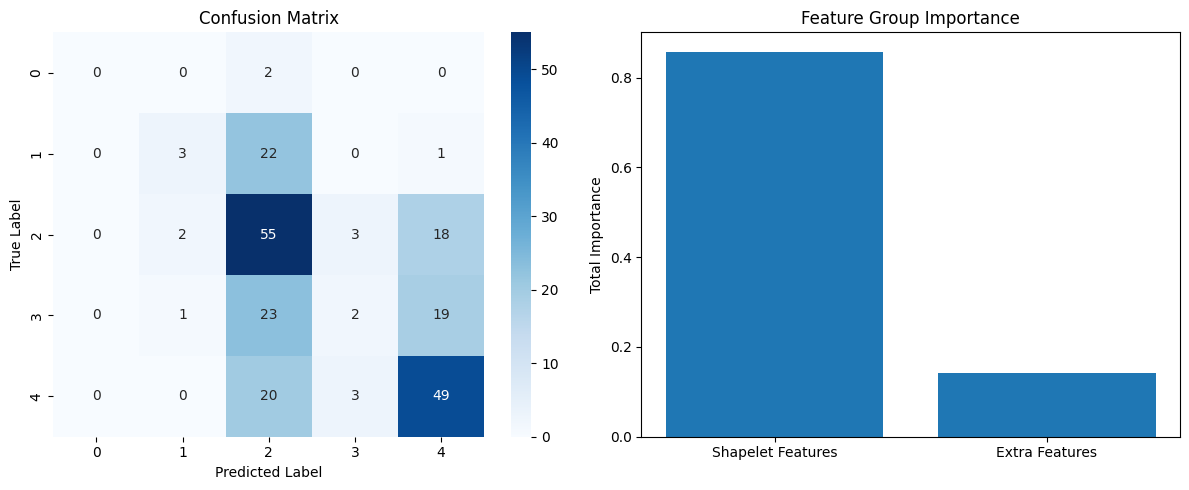


Analisi Shapelets:
Numero totale shapelets: 22


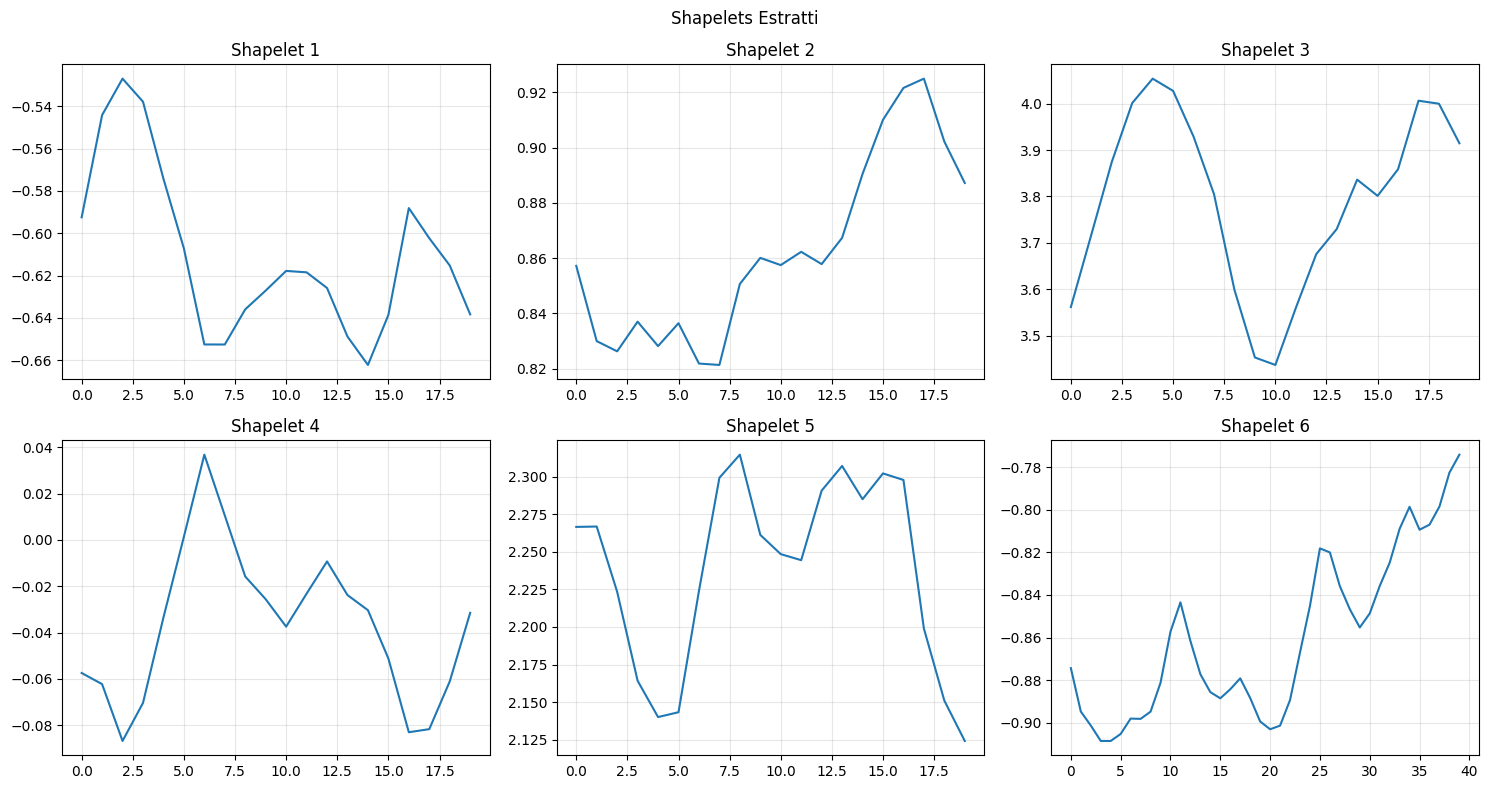

ModuleNotFoundError: No module named 'shapelet_analyzer'

In [62]:
# Dopo aver eseguito la tua pipeline
classifier = TimeSeriesShapeletClassifier()
classifier.run_complete_pipeline(filepath)

# Analizza le shapelets estratte
from shapelet_analyzer import analyze_existing_classifier
analyzer = analyze_existing_classifier(classifier)